## Numerical integration using Simpson's Rule

**Date:** 15 Jun 23

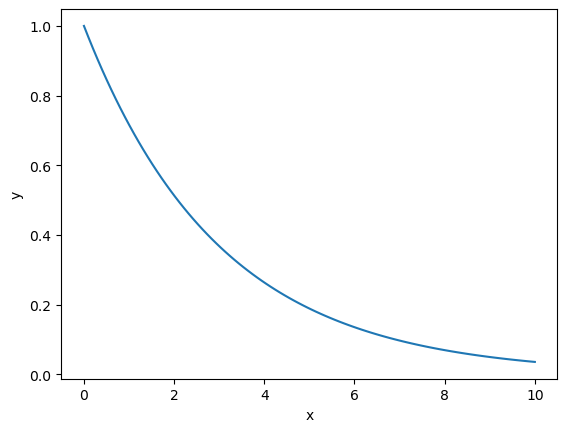

In [85]:
import numpy as np
from scipy import integrate
from matplotlib import pyplot as plt

x = np.linspace(0,10,100)
y = np.exp(-x/3)

fig,ax = plt.subplots()
ax.plot(x,y)
ax.set(xlabel="x", ylabel="y")
plt.show()

The area under the curve is:
$$
\begin{align}
    \int_0^{10} e^{-x/3}dx &= \left[-3e^{-x/3}\right]_{0}^{10} \\
    &= 3(1 - e^{-10/3})\\
    &\approx 2.89297801996
\end{align}
$$

Compute numerically:

In [86]:
area = integrate.simpson(y,x,even="first")
print(f"area = {area}")

area = 2.8929783868004573


Now check as a function of $x$:
$$
Y = 3(1 - e^{-x/3})
$$

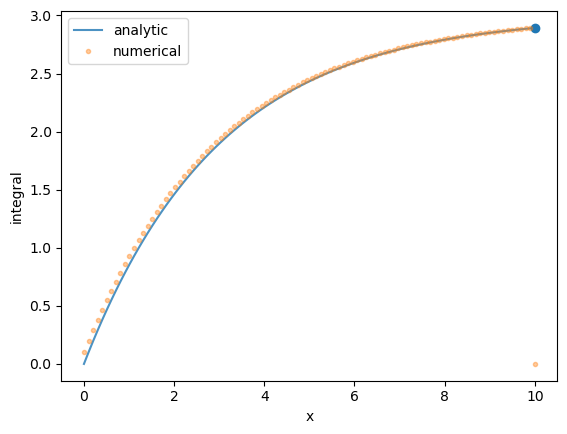

In [87]:
cumulative_sum = np.zeros_like(x)
for k in range(1,len(x)):
    cumulative_sum[k-1] = integrate.simpson(y[:k+1],x[:k+1],even="first")
    
fig,ax = plt.subplots()
ax.plot(x, 3*(1 - np.exp(-x/3)), alpha = 0.8, label="analytic")
ax.plot(x, cumulative_sum, '.', alpha = 0.4, label="numerical")
ax.set(xlabel="x", ylabel="integral")
ax.scatter(x[-1], area)
plt.legend()
plt.show()

So it works...now try something similar to the GS code

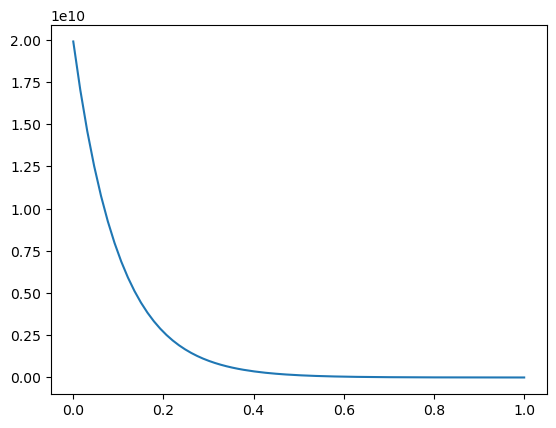

In [106]:
# Set constants
cs = 1e6
R_star = 1e4
B_star = 1e8
G = 6.67e-11
M_sol = 1.989e30
M_star = 1.4*M_sol
ma = 1e-5*M_sol
x0 = cs*cs*R_star*R_star/(G*M_star)
psi_0=np.sqrt(cs*cs*ma/x0/x0/x0)
psi_star = B_star*R_star**2/2
bratio = 10
n_contours = 127
dmu = 1.0/n_contours
mu_levels = np.zeros(n_contours)

# create psi_levels
for i in range(0,n_contours):
        contour_mesh_value = (n_contours - i)/(n_contours + 1.0)/dmu # Decide on required location of psi levels
        mu_levels[i] = contour_mesh_value*dmu
        
psi_levels = (psi_star/psi_0)*(1-mu_levels*mu_levels)

x00 = psi_levels*psi_0


x = np.append(np.array([0]), x00)
x[-1] = psi_star

dmdpsi_pm04 = ma/2.0*bratio/psi_star*np.exp(-x/psi_star*bratio)/(1.0 - np.exp(-bratio))

# plot
fig,ax = plt.subplots()
ax.plot(x/psi_star,dmdpsi_pm04)
plt.show()

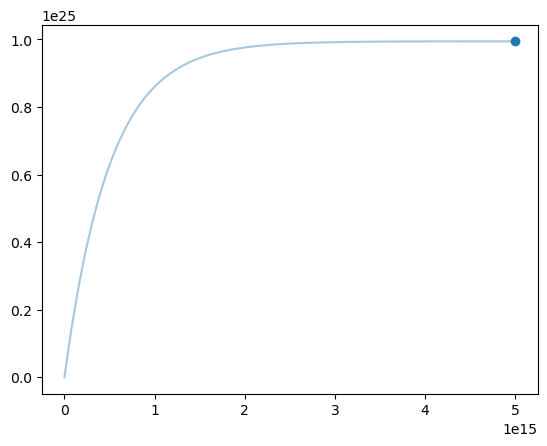

In [107]:
# integrate dmdpsi numerically

final_mass = integrate.simpson(dmdpsi_pm04,x, even="first")

cumulative_mass = ma/2.0*(1 - np.exp(-x/psi_star*bratio))/(1 - np.exp(-bratio))

fig,ax = plt.subplots()
ax.plot(x, cumulative_mass, alpha = 0.4)
ax.scatter(x[-1], final_mass)
plt.show()

So the issue has been that the integration needs to be between $(0,\psi_{max})$, not $(\psi_{min},\psi_{max})$.